# Onboarding Week NBP

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Exploring the Dataset

In [118]:
df_aab_ps = pd.read_csv('pictureSequence.csv', header=None)
df_aab_bo = pd.read_csv('blockOrder.csv', header=None)
df_aab_cr = pd.read_csv('correctReaction.csv', header=None)
df_aab_ar = pd.read_csv('actualReaction.csv', header=None)
df_aab_rt = pd.read_csv('reactionTime.csv', header=None)

## Exercise 1
### Dropping the Test Rows

In [119]:
droprows = list(range(0, 4)) + list(range(44, 48))
ps_wt = df_aab_ps.drop(index=droprows)
bo_wt = df_aab_bo
cr_wt = df_aab_cr.drop(index=droprows)
ar_wt = df_aab_ar.drop(index=droprows)
rt_wt = df_aab_rt.drop(index=droprows)


## Exercise 2 + 3

In [120]:
threshold = 0.15

invalid = (
    (cr_wt != ar_wt)       # Is the Correct Reaction the same as the Actual Reaction?
    | ar_wt.isna()         # Are the values already empty?
    | rt_wt.isna()
    | (rt_wt <= threshold) # Reaction Time Threshold Comparison
)

df_ps = ps_wt.mask(invalid)
df_cr = cr_wt.mask(invalid)
df_ar = ar_wt.mask(invalid)
df_rt = rt_wt.mask(invalid)
df_bo = df_aab_bo.copy()

# Checking, if all of the Dataframes have the same amount of NaN Values
for name, d in zip(['ps','cr','ar','rt'], [df_ps, df_cr, df_ar, df_rt]):
    print(name, d.shape, d.isna().sum().sum())

ps (80, 122) 345
cr (80, 122) 345
ar (80, 122) 345
rt (80, 122) 345


## Exercise 4


In [121]:
n_trials = df_rt.shape[0]
valid_per_col = df_rt.notna().sum() # Trickster Moment

participant = np.arange(df_rt.shape[1]) // 2 # Because of the two Blocks we gotta divide the previous result
valid_per_participant = valid_per_col.groupby(participant).sum()
ratio = valid_per_participant / (2 * n_trials)

excluded = ratio[ratio < 0.9].index
print(f"Excluded Participants: {len(excluded)} of {len(ratio)}", list(excluded))

keep_cols = [c for c, p in zip(df_rt.columns, participant) if p not in excluded]
df_ps, df_cr, df_ar, df_rt = [d[keep_cols] for d in (df_ps, df_cr, df_ar, df_rt)]
df_bo = df_bo[keep_cols]

Excluded Participants: 3 of 61 [40, 42, 43]


## Exercise 5

In [122]:
 def winsorize_sd(col, k=2):
    m, s = col.mean(), col.std()
    return col.clip(lower=m - k*s, upper=m + k*s)

df_rt_w = df_rt.apply(winsorize_sd)   # spaltenweise, NaN bleibt NaN

## Exercise 6

In [123]:
df_rt_log = np.log(df_rt_w)   # Applying natural Logarithm

df_rt_w.to_csv('reactionTime_winsorized.csv', index=False)
df_rt_log.to_csv('reactionTime_winsorized_log.csv', index=False)

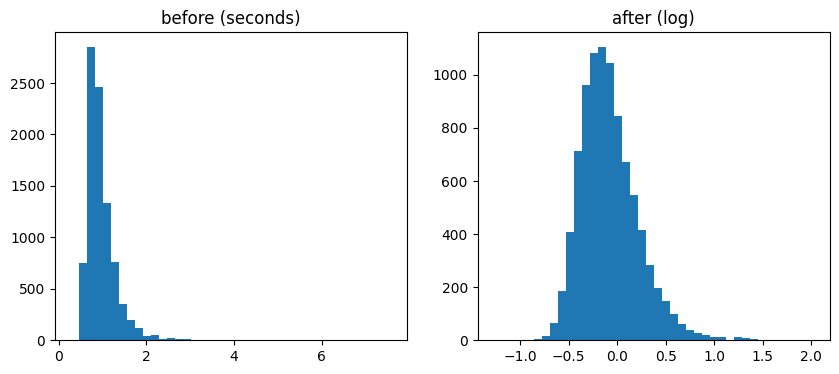

NaNs the same? True


In [124]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df_rt_w.stack(), bins=40)
axes[0].set_title('before (seconds)')
axes[1].hist(df_rt_log.stack(), bins=40)
axes[1].set_title('after (log)')
plt.show()

print("NaNs the same?", df_rt_w.isna().sum().sum() == df_rt_log.isna().sum().sum())

## Exercise 7

In [125]:
rows = []
for j, col in enumerate(df_rt.columns):
    order = df_bo[col].iloc[0]
    block = col % 2
    first_congruent = order in (1, 3)
    congruent = first_congruent if block == 0 else not first_congruent
    for t in df_rt.index:
        rows.append({
            'participant': col // 2,
            'block': block + 1,
            'trial': t,
            'picture': df_ps.at[t, col],
            'rt': df_rt_w.at[t, col],
            'log_rt': df_rt_log.at[t, col],
            'condition': 'Congruent' if congruent else 'Incongruent',
        })

long = pd.DataFrame(rows).dropna(subset=['rt'])   # HIER ist dropna ok
long['valence'] = np.where(long['picture'] <= 44, 'Positive', 'Negative')
long['cond4'] = long['condition'] + '-' + long['valence']

print(long['cond4'].value_counts())

cond4
Congruent-Positive      2314
Congruent-Negative      2264
Incongruent-Positive    2221
Incongruent-Negative    2191
Name: count, dtype: int64


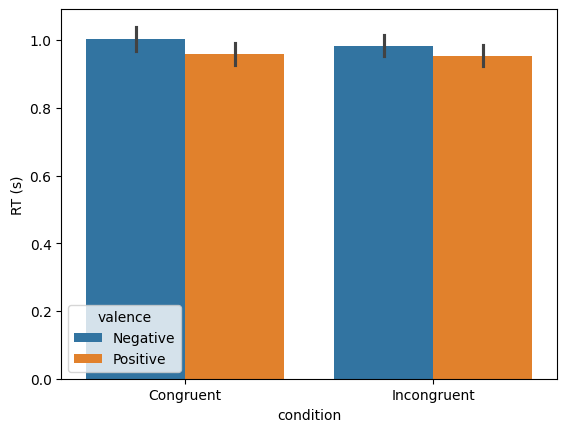

In [126]:
agg = (long.groupby(['participant', 'condition', 'valence'], as_index=False)['rt']
           .mean())
sns.barplot(data=agg, x='condition', y='rt', hue='valence', errorbar='se')
plt.ylabel('RT (s)')
plt.show()